# SAR L2 Validation — Steps 4 & 5

This notebook demonstrates:
- **Step 4a** — SAR patch extraction (`collocation_patches.nc`)
- **Step 4b** — Validation statistics (bias, RMSE, correlation)
- **Step 5**  — Visualisation (scatter, geographic, statistics bar chart, residuals)

Prerequisites: steps 1–3 must already have been run (i.e. `datatree.nc` and
`collocation_results.nc` must exist in the data directory).

In [ ]:
import xarray as xr
from pathlib import Path

# ── Edit this path to match your data directory ──────────────────────────────
DATA_DIR = Path(
    "/home/chvan0015/git/sar-l2-validation-toolbox/data/2026-07-05-180000-2026-07-05-220000_-15.00_0.00_35.00_60.00"
)
RECIPE_PATH = Path("/home/chvan0015/git/sar-l2-validation-toolbox/recipes/wind_europe.yaml")
# ─────────────────────────────────────────────────────────────────────────────

print("Data directory:", DATA_DIR)
print("Files present:", [f.name for f in DATA_DIR.iterdir() if f.is_file()])

Data directory: /home/chvan0015/git/sar-l2-validation-toolbox/data/2026-06-24-000000-2026-06-24-180000_-20.00_0.00_35.00_60.00
Files present: ['collocation_results.nc', 'validation_statistics_owiWindSpeed_vs_WSPD.nc', 'collocation_patches.nc', 'validation_statistics_owiWindSpeed_vs_WSPD.csv', 'validation_statistics_owiWindDirection_vs_WDIR.csv', 'validation_statistics_owiWindDirection_vs_WDIR.nc', 'datatree.nc', 'download_metadata.json', 'validation_report.pdf']


## Load DataTree and collocation results

In [ ]:
datatree = xr.open_datatree(str(DATA_DIR / "datatree.nc"), engine="netcdf4")
collocation_ds = xr.open_dataset(str(DATA_DIR / "collocation_results.nc"))

print("DataTree structure:")
print(datatree)
print("\nCollocation dataset:")
print(collocation_ds)

DataTree structure:
<xarray.DataTree>
Group: /
├── Group: /sar
│   ├── Group: /sar/S1A_IW_OCN__2SDV_20260624T060121_20260624T060146_065107_0834EE_6734.SAFE
│   │       Dimensions:            (y: 166, x: 264)
│   │       Coordinates:
│   │           lon                (y, x) float32 175kB ...
│   │           lat                (y, x) float32 175kB ...
│   │           time               datetime64[ns] 8B ...
│   │       Dimensions without coordinates: y, x
│   │       Data variables:
│   │           owiWindSpeed       (y, x) float32 175kB ...
│   │           owiWindDirection   (y, x) float32 175kB ...
│   │           owiNrcs            (y, x) float32 175kB ...
│   │           owiIncidenceAngle  (y, x) float32 175kB ...
│   │           owiHeading         (y, x) float32 175kB ...
│   │           owiWindQuality     (y, x) float32 175kB ...
│   │           owiMask            (y, x) int8 44kB ...
│   │       Attributes:
│   │           data_type:         sar_l2_ocn
│   │           source:    

In [16]:
# Inspect available variables
print("Collocation variables:")
for v in sorted(collocation_ds.data_vars):
    print(f"  {v}: {collocation_ds[v].dtype}")

Collocation variables:
  collocation_type: <U14
  sar_lat: float64
  sar_lon: float64
  sar_owiHeading: float64
  sar_owiIncidenceAngle: float64
  sar_owiMask: float64
  sar_owiNrcs: float64
  sar_owiWindDirection: float64
  sar_owiWindQuality: float64
  sar_owiWindSpeed: float64
  sar_scene_name: <U72
  sar_x_idx: int64
  sar_y_idx: int64
  spatial_distance_km: float64
  temporal_distance_minutes: float64
  val_HCDT: float64
  val_HCSP: float64
  val_VAVH: float64
  val_VHM0: float64
  val_WDIR: float64
  val_WSPD: float64
  val_depth: float64
  val_lat: float64
  val_lon: float64
  val_source: <U6


## Load recipe

In [17]:
from sar_validation.core.recipe import Recipe

recipe = Recipe.from_yaml(RECIPE_PATH)
print(f"Recipe: {recipe.config.name}")
print(f"Variable: {recipe.config.variable}")

Recipe: wind_europe
Variable: wind


## Step 4a — SAR patch extraction

Extract a 5×5 pixel neighbourhood from the SAR swath around each collocated point.
The result is saved to `collocation_patches.nc`.

<xarray.Dataset> Size: 77kB
Dimensions:                      (collocation: 38, patch_y: 5, patch_x: 5)
Coordinates:
    time                         (collocation) datetime64[ns] 304B ...
    val_time                     (collocation) datetime64[ns] 304B ...
    val_id                       (collocation) <U15 2kB ...
  * patch_y                      (patch_y) int64 40B -2 -1 0 1 2
  * patch_x                      (patch_x) int64 40B -2 -1 0 1 2
Dimensions without coordinates: collocation
Data variables: (12/32)
    sar_lon                      (collocation) float64 304B ...
    sar_lat                      (collocation) float64 304B ...
    val_lon                      (collocation) float64 304B ...
    val_lat                      (collocation) float64 304B ...
    spatial_distance_km          (collocation) float64 304B ...
    temporal_distance_minutes    (collocation) float64 304B ...
    ...                           ...
    sar_patch_owiWindDirection   (collocation, patch_y, patch_

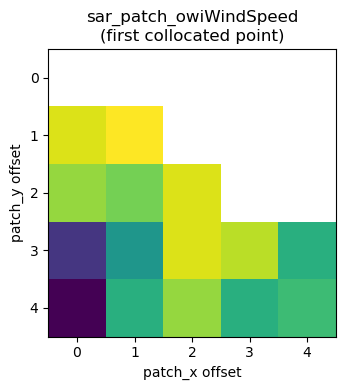

In [18]:
from sar_validation.core.patch_extractor import run_patch_extraction

PATCH_SIZE = 5  # pixels; must be odd

patches_ds = run_patch_extraction(
    collocation_ds=collocation_ds,
    datatree=datatree,
    patch_size=PATCH_SIZE,
    base_dir=DATA_DIR,
)

if patches_ds is not None:
    print(patches_ds)
    # Show the first patch for the first SAR variable
    patch_vars = [v for v in patches_ds.data_vars if v.startswith("sar_patch_")]
    if patch_vars:
        import matplotlib.pyplot as plt
        v = patch_vars[0]
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(patches_ds[v].isel(collocation=0).values, origin="upper", cmap="viridis")
        ax.set_title(f"{v}\n(first collocated point)")
        ax.set_xlabel("patch_x offset")
        ax.set_ylabel("patch_y offset")
        plt.tight_layout()
        plt.show()

## Step 4b — Validation statistics

**Note on wind direction convention:** ASCAT/OSI-SAF scatterometer files report
wind direction in the *oceanographic* convention (direction the wind blows
*towards*). This is converted to the *meteorological* convention (direction
the wind blows *from*) — the convention used by Sentinel-1 OWI
(`owiWindDirection`) and the Copernicus Marine in-situ `WDIR` code — during
step 2 ingestion (`DataTreeConverter.from_scatterometer_nc`, a 180° rotation
applied once, before anything is written to `datatree.nc`). So `val_WDIR` here
is already directly comparable to `sar_owiWindDirection` for every source,
including scatterometer.

In [19]:
from sar_validation.core.statistics import run_statistics

stats_map = run_statistics(collocation_ds, recipe, DATA_DIR)

for key, ds in stats_map.items():
    print(f"\n── {key} ──")
    print(ds.to_dataframe())


── owiWindSpeed_vs_WSPD ──
                  N      bias       std      rmse   correlation  scatter_index
source                                                                        
6100198           6  1.967412  0.766812  2.088231           NaN       0.809392
6100417          12  2.461232  0.876046  2.600224  9.207666e-01       0.843886
6200305           2 -1.906148  0.070711  1.906804           NaN       0.555919
Smile             6 -1.310157  0.138435  1.316237  2.928429e-15       0.386088
VillajoyosaBuoy   8  0.363953  0.381487  0.509709           NaN       0.211329

── owiWindDirection_vs_WDIR ──
                  N        bias         std        rmse  correlation  \
source                                                                 
6100198           6 -204.986375    6.572671  205.074167          NaN   
6100417          12 -197.878100  141.511366  239.817473    -0.355182   
6200305           2   37.103064    5.768813   37.326625          NaN   
Smile             6    3.69

/home/chvan0015/miniforge3/envs/sar_validation/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/chvan0015/miniforge3/envs/sar_validation/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/chvan0015/miniforge3/envs/sar_validation/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/chvan0015/miniforge3/envs/sar_validation/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Step 5 — Visualisation

### 5a. Scatter plot

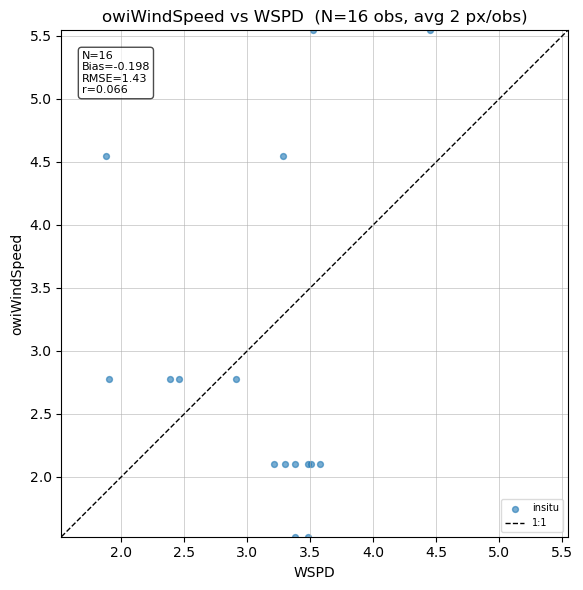

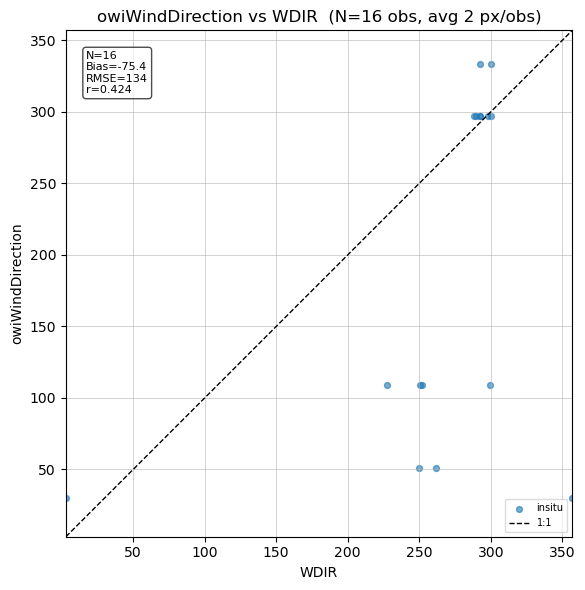

In [20]:
from sar_validation.core.visualization import plot_scatter
from sar_validation.core._variable_map import infer_variable_pairs
import matplotlib.pyplot as plt

pairs = infer_variable_pairs(recipe.config.variable)

for sar_var, val_var in pairs:
    fig = plot_scatter(collocation_ds, sar_var, val_var, by_source=True)
    if fig:
        plt.show()

### 5b. Interactive scatter (requires plotly)

In [8]:
try:
    for sar_var, val_var in pairs:
        fig = plot_scatter(collocation_ds, sar_var, val_var, interactive=True)
        if fig:
            fig.show()
except ImportError as e:
    print(f"Skipping interactive scatter: {e}")

### 5c. Geographic plot — one subplot per SAR scene

  owiWindSpeed [point_vs_layer]


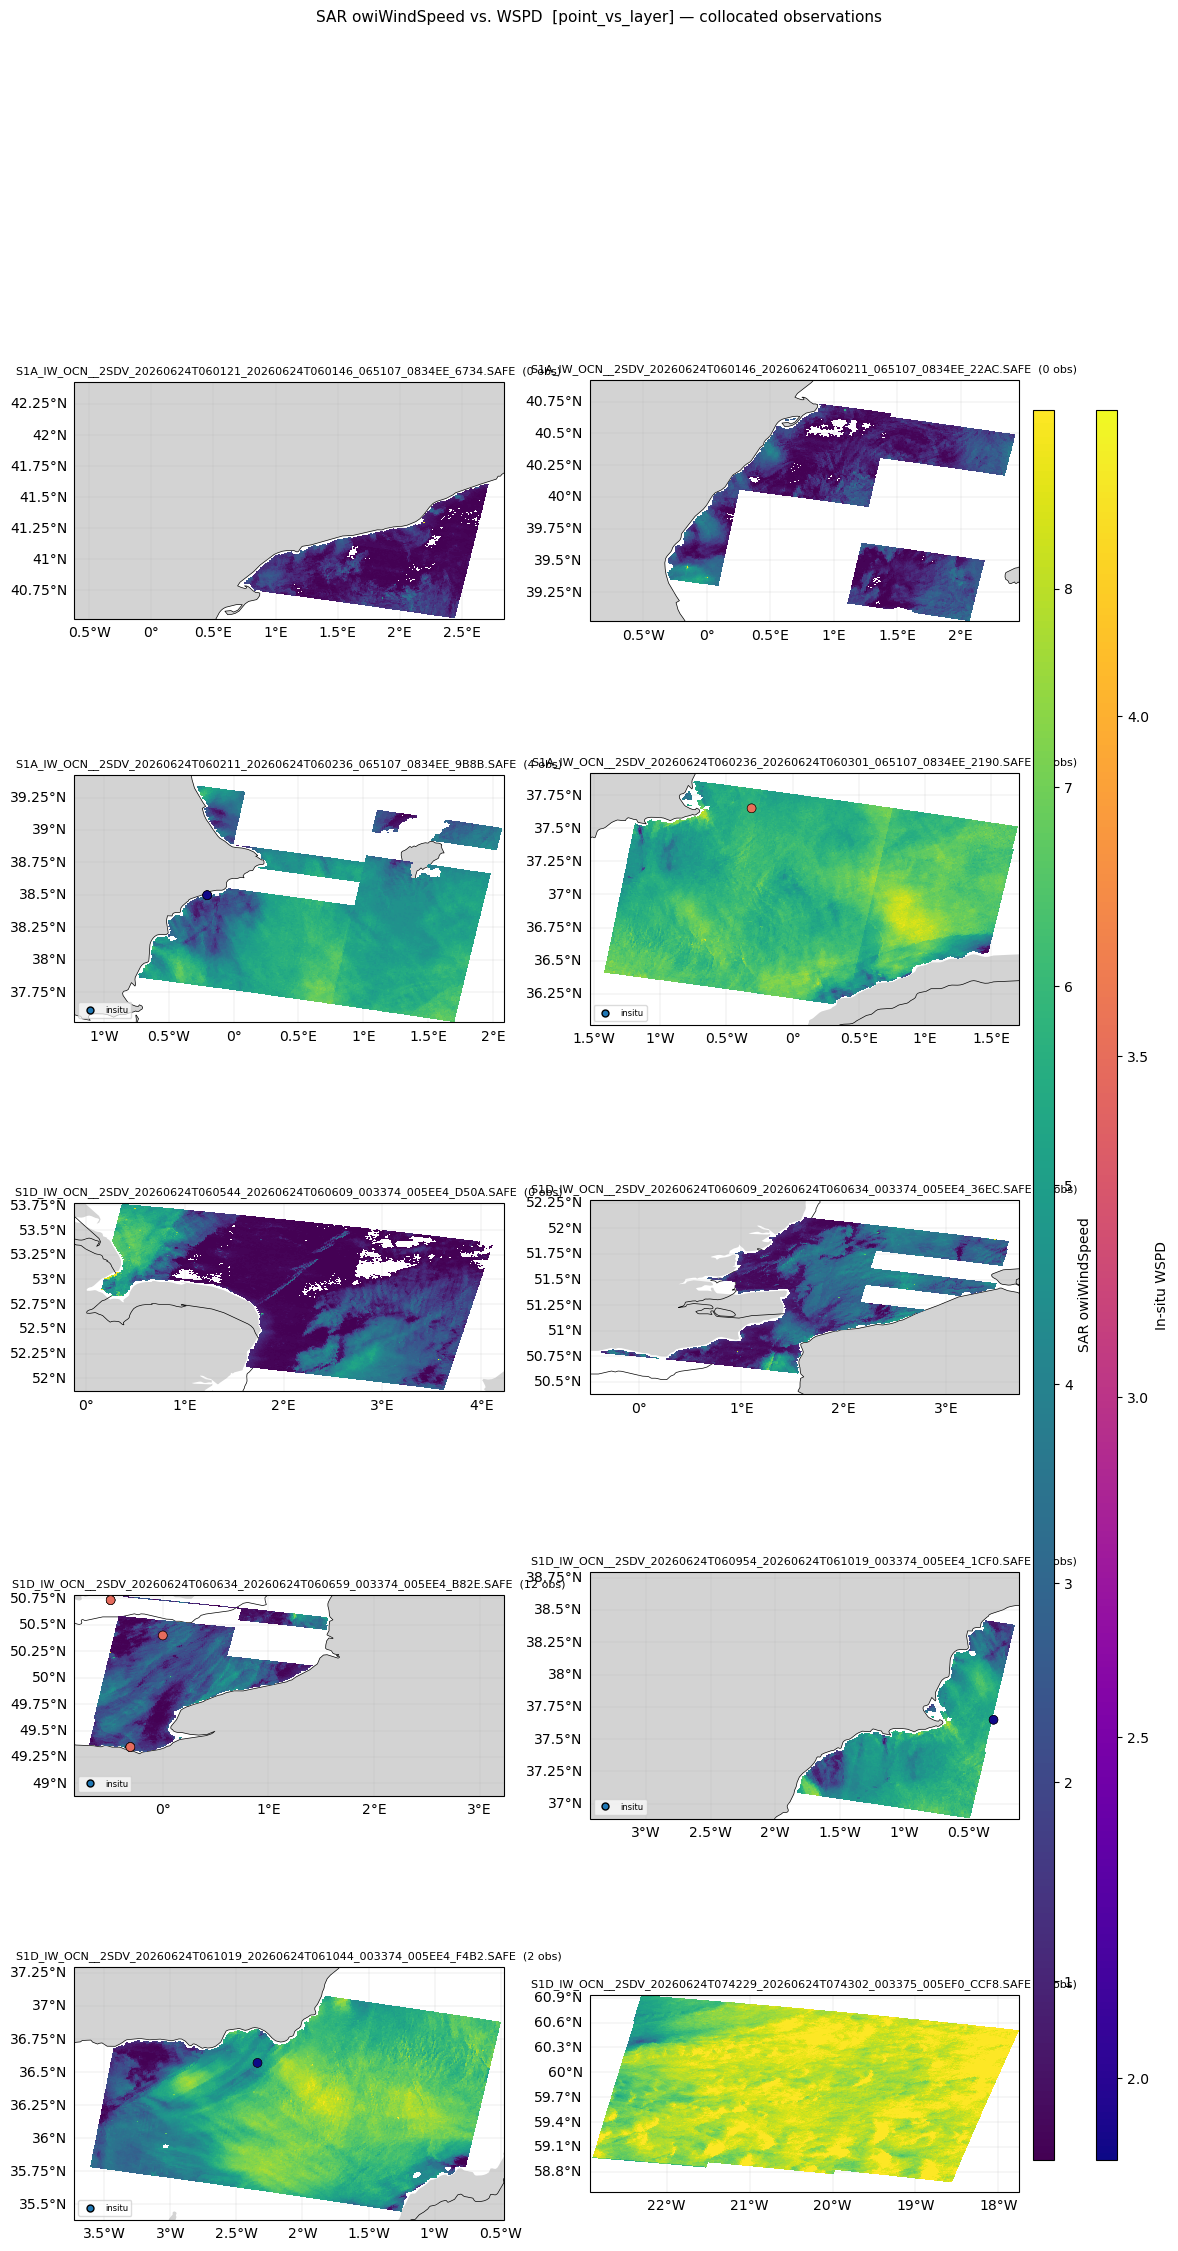

  owiWindDirection [point_vs_layer]


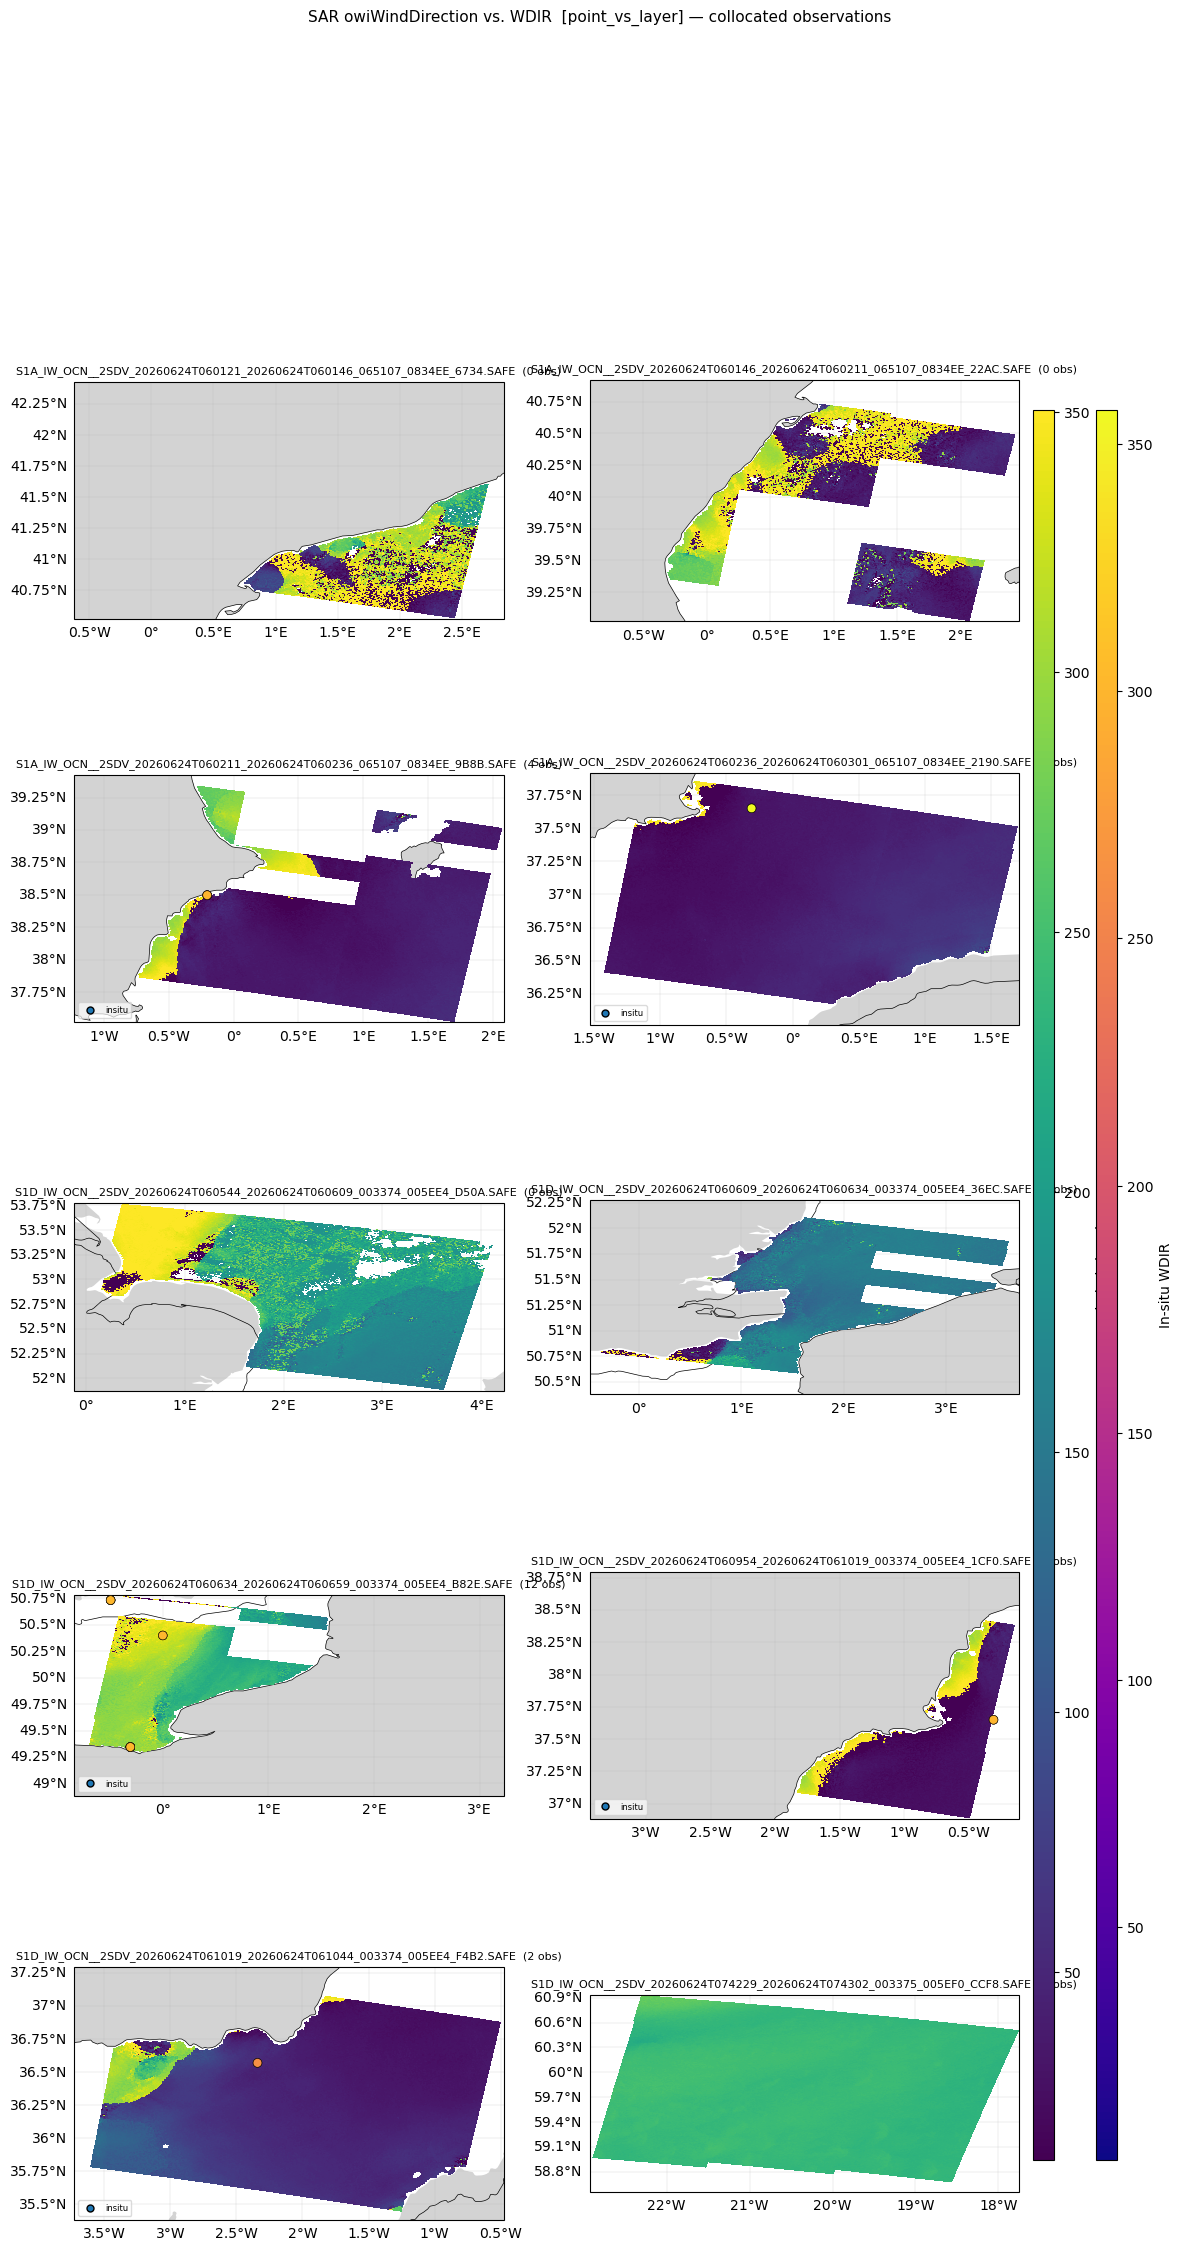

In [21]:
from sar_validation.core.visualization import plot_geographic

for sar_var, val_var in pairs:
    try:
        # Returns dict[collocation_type → Figure] by default (split_by="collocation_type")
        result = plot_geographic(datatree, collocation_ds, sar_var, val_var, ncols=2)
        if isinstance(result, dict):
            for group_name, fig in result.items():
                print(f"  {sar_var} [{group_name}]")
                plt.show()
                plt.close(fig)
        elif result:
            plt.show()
    except Exception as e:
        print(f"Geographic plot failed for {sar_var}: {e}")


### 5d. Interactive geographic map (requires folium)

In [14]:
try:
    for sar_var, val_var in pairs:
        m = plot_geographic(datatree, collocation_ds, sar_var, interactive=True)
        display(m)  # renders inline in Jupyter
except ImportError as e:
    print(f"Skipping interactive map: {e}")
except Exception as e:
    print(f"Interactive map failed: {e}")

### 5e. Statistics bar chart

/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)


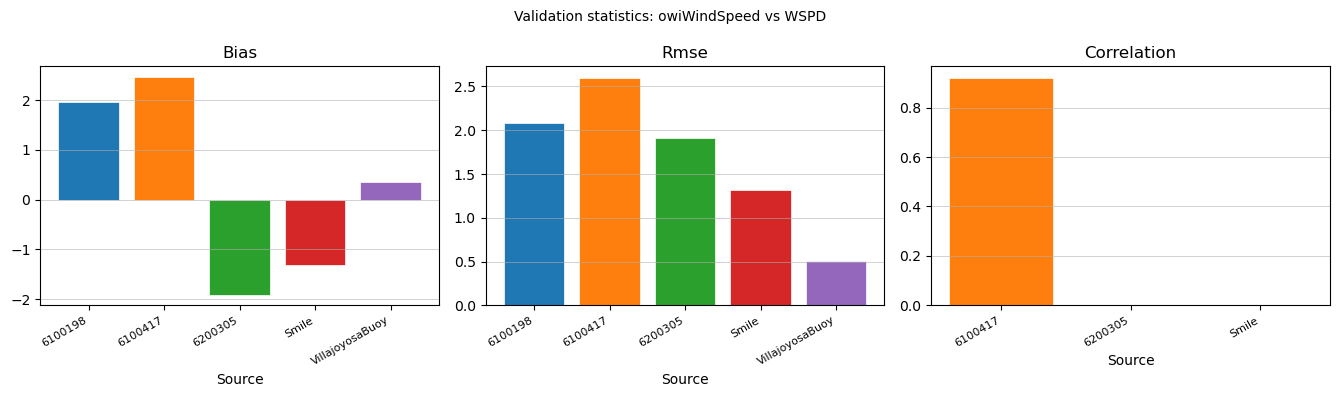

/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)


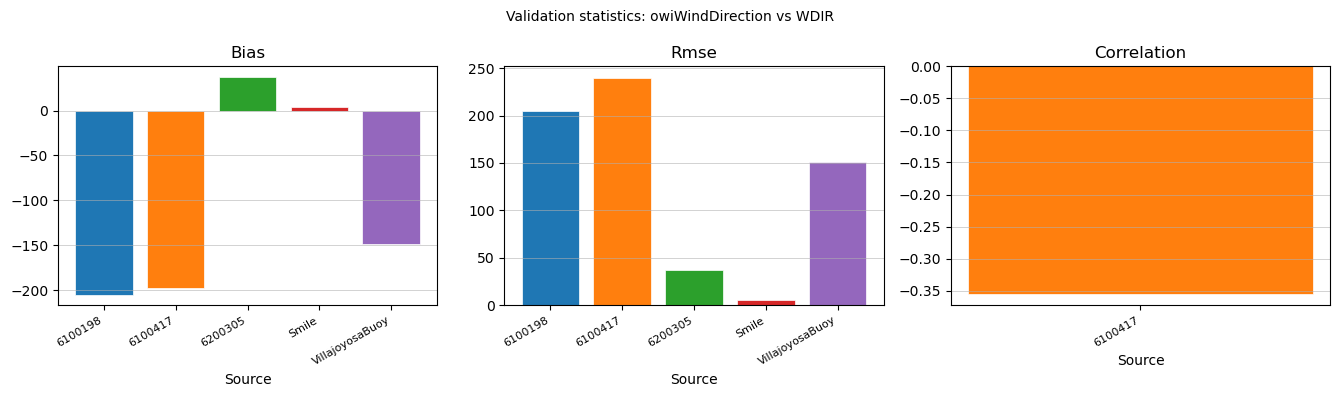

In [11]:
from sar_validation.core.visualization import plot_statistics

for key, stats_ds in stats_map.items():
    fig = plot_statistics(stats_ds, metrics=["bias", "rmse", "correlation"])
    if fig:
        plt.show()

### 5f. Residuals histogram

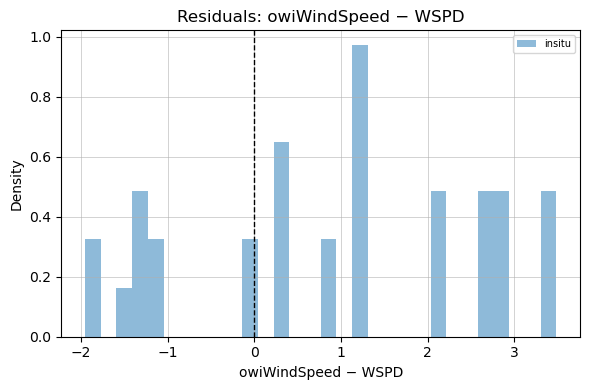

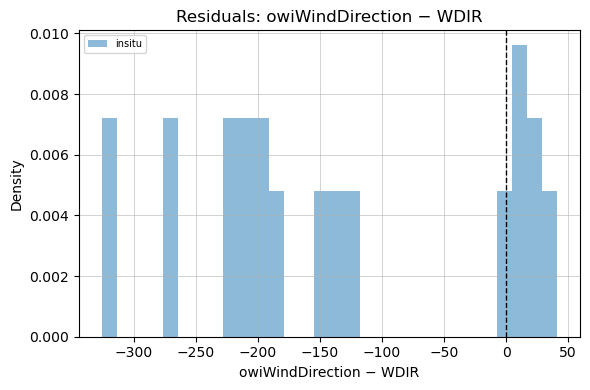

In [12]:
from sar_validation.core.visualization import plot_residuals

for sar_var, val_var in pairs:
    fig = plot_residuals(collocation_ds, sar_var, val_var, by_source=True)
    if fig:
        plt.show()

### 5g. Full validation report

Run all plots at once and save PNGs to `<data_dir>/plots/`.

/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sources, rotation=30, ha="right", fontsize=8)
/home/chvan0015/git/sar-l2-validation-toolbox/sar_validation/core/visualization.py:634: UserWarning: set_ticklabels() should only be used with a fixed 

Saved PNG files:
  owiWindDirection_vs_WDIR_geographic_point_vs_layer.png
  owiWindDirection_vs_WDIR_residuals.png
  owiWindDirection_vs_WDIR_scatter.png
  owiWindDirection_vs_WDIR_statistics.png
  owiWindSpeed_vs_WSPD_geographic_point_vs_layer.png
  owiWindSpeed_vs_WSPD_residuals.png
  owiWindSpeed_vs_WSPD_scatter.png
  owiWindSpeed_vs_WSPD_statistics.png


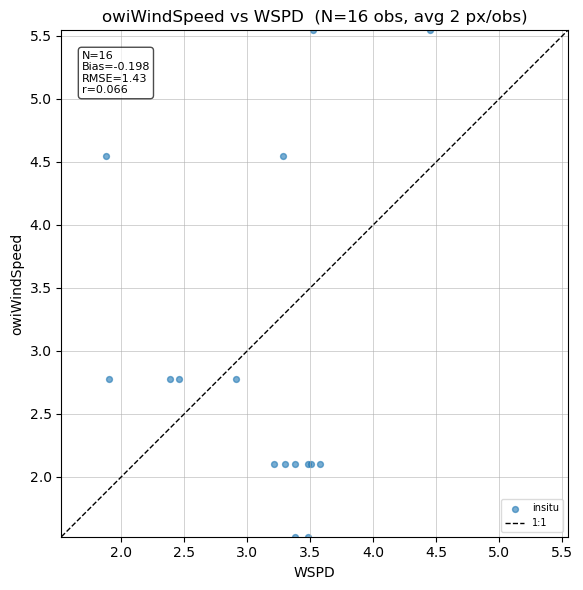

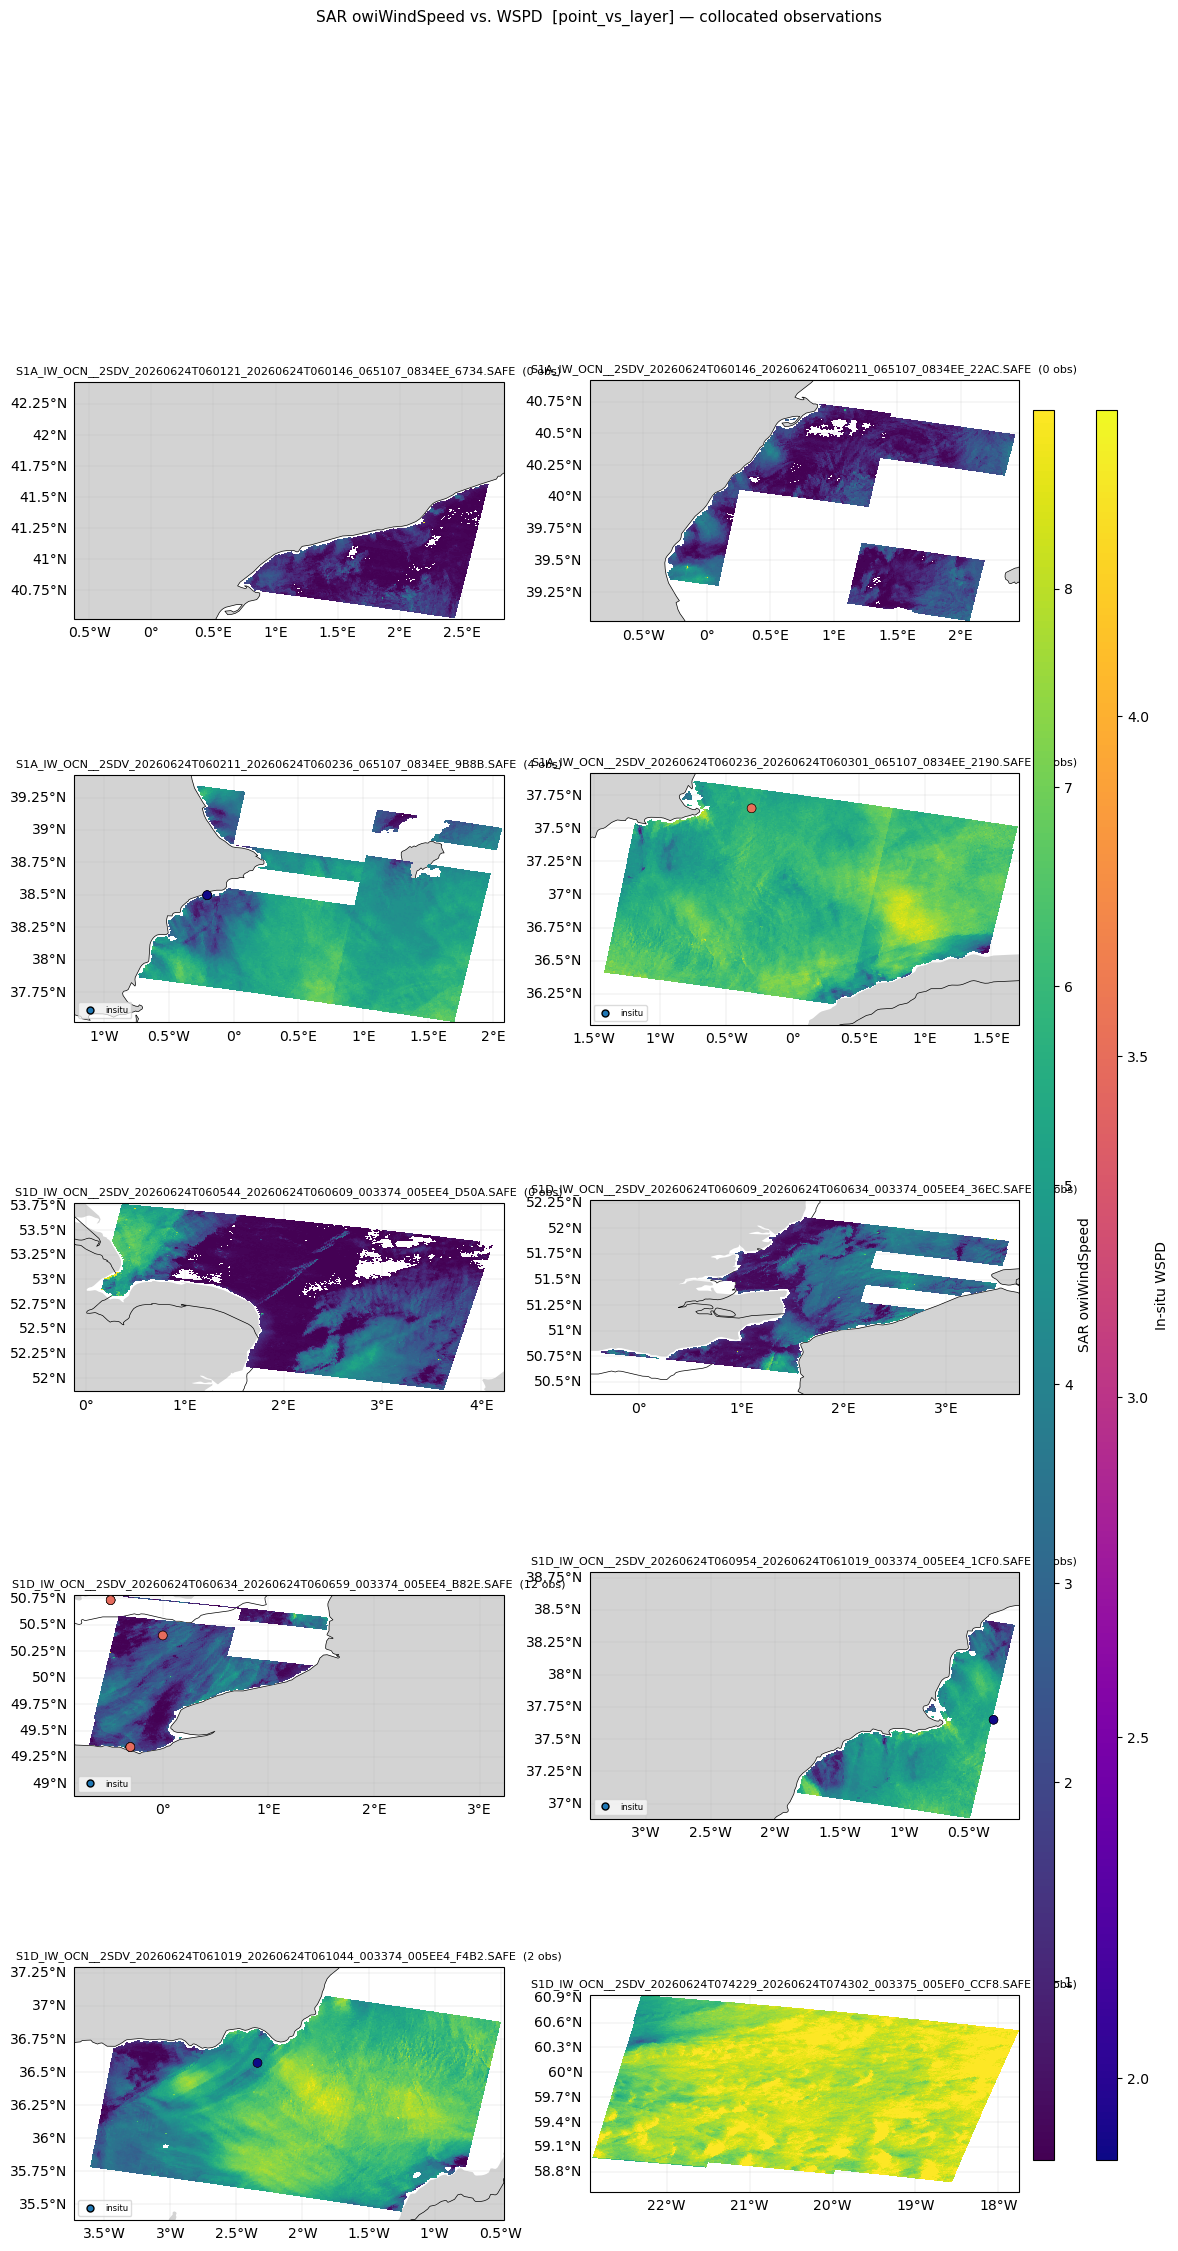

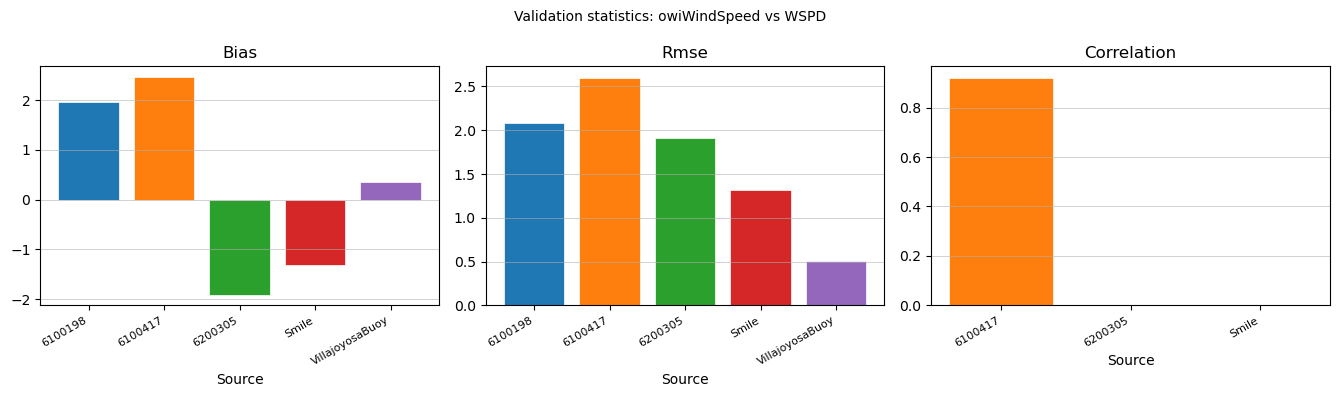

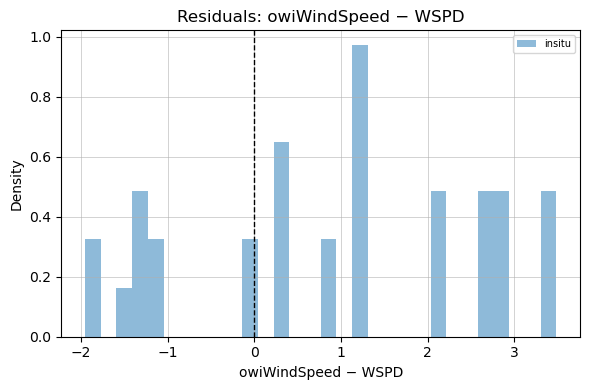

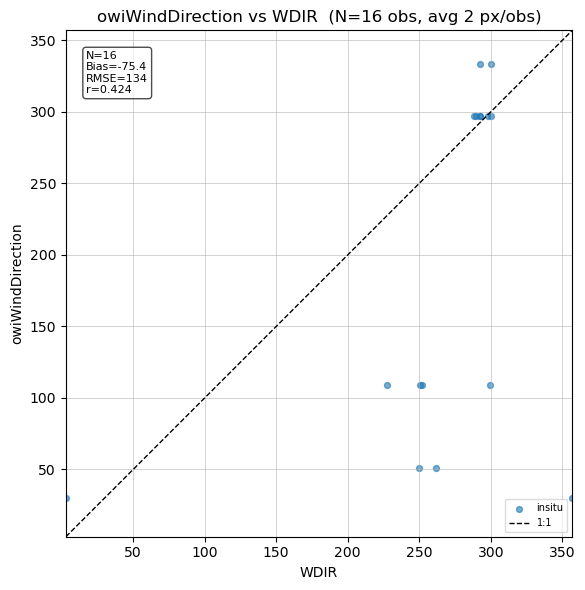

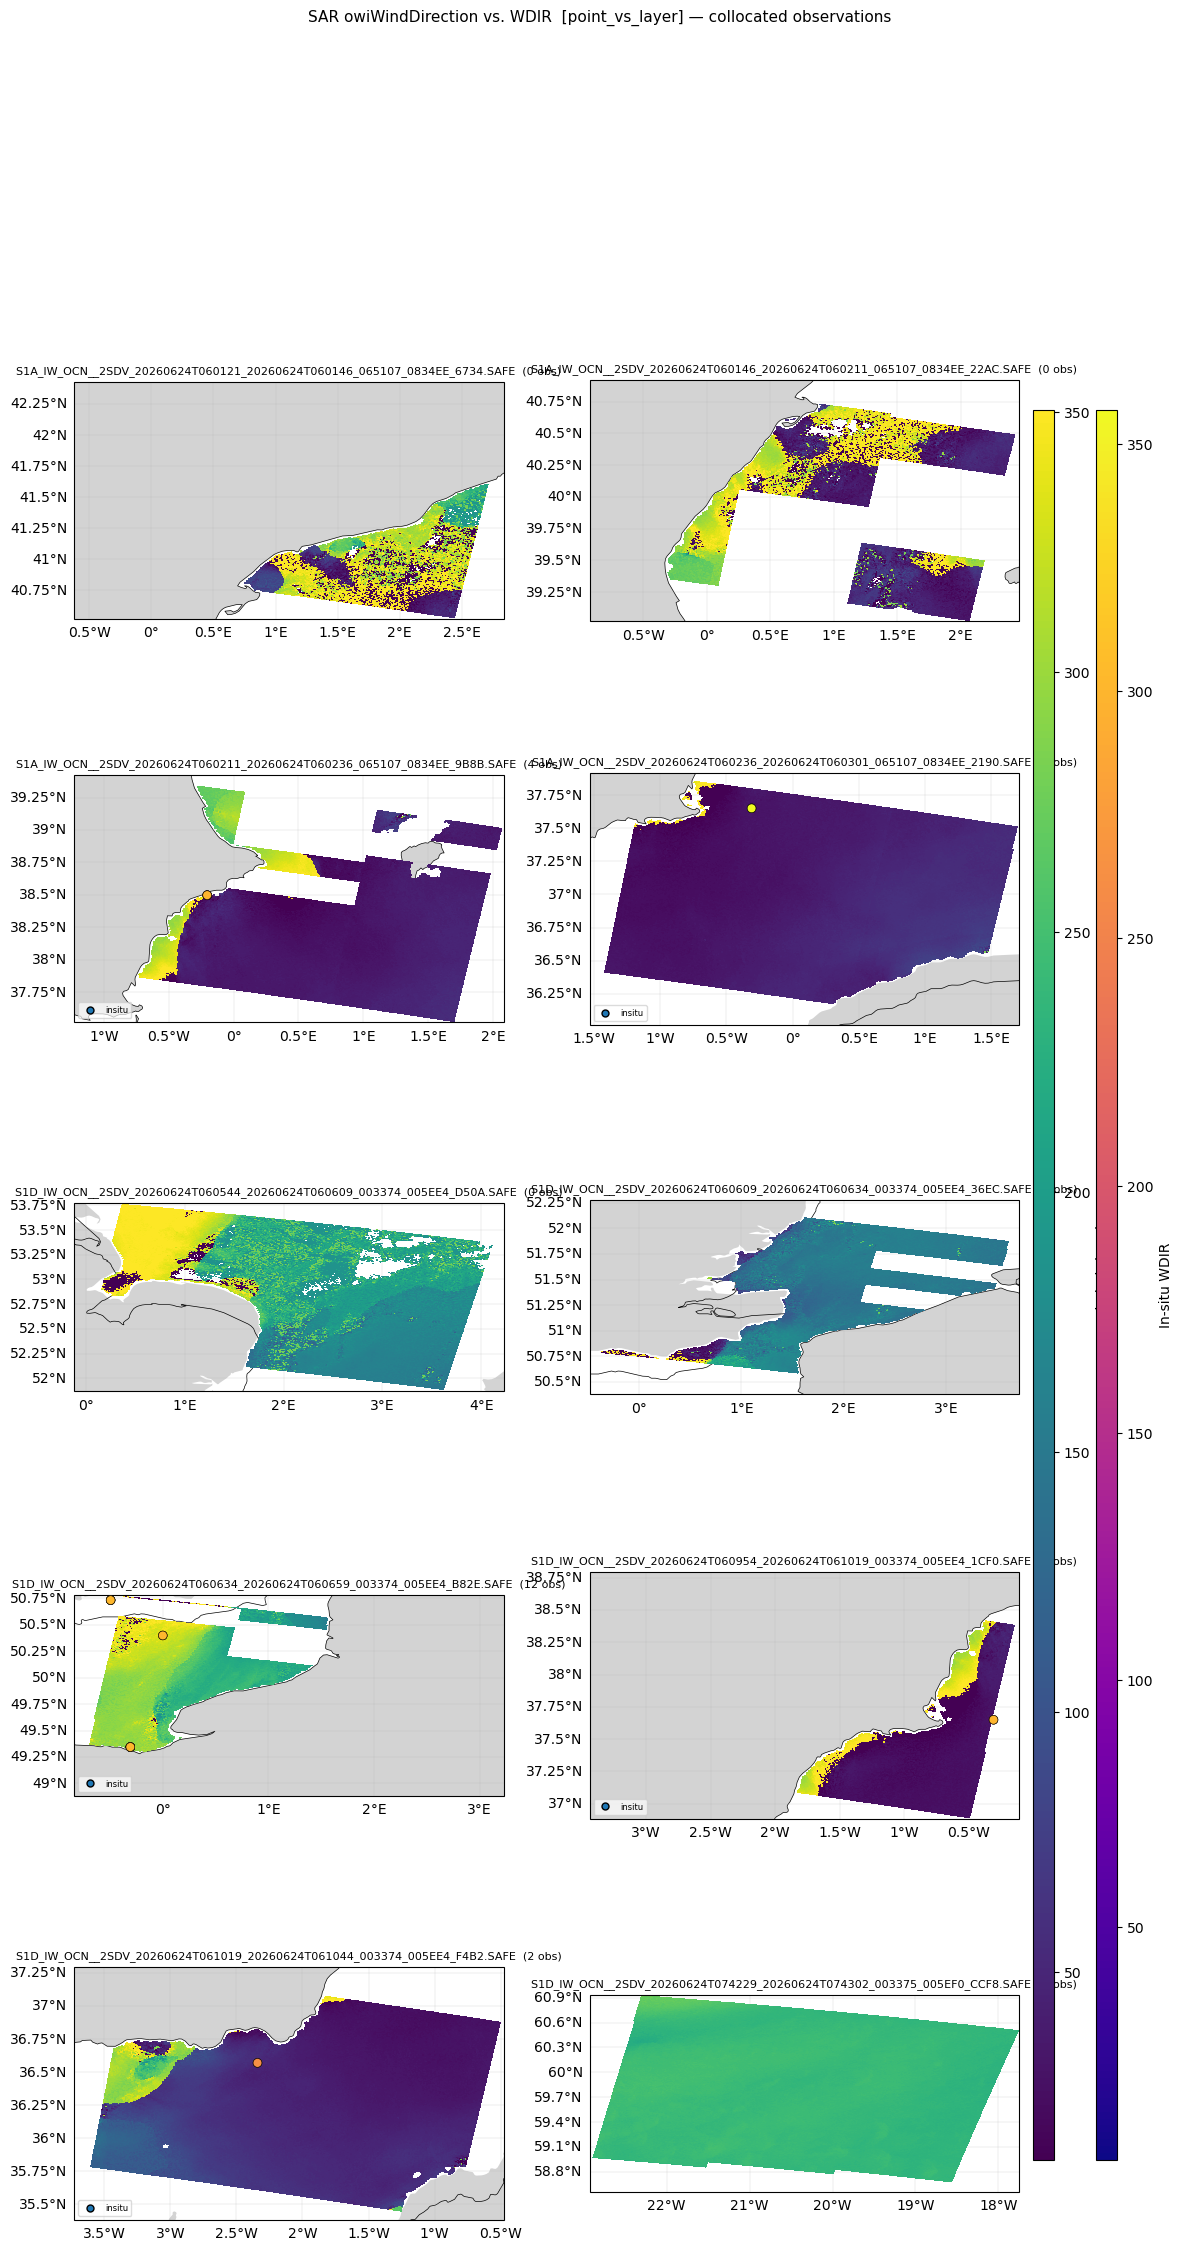

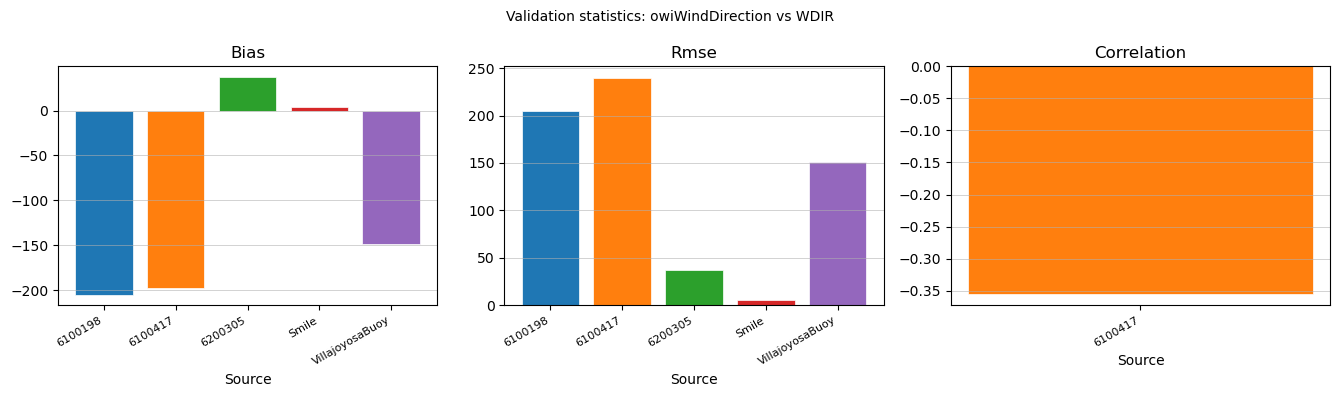

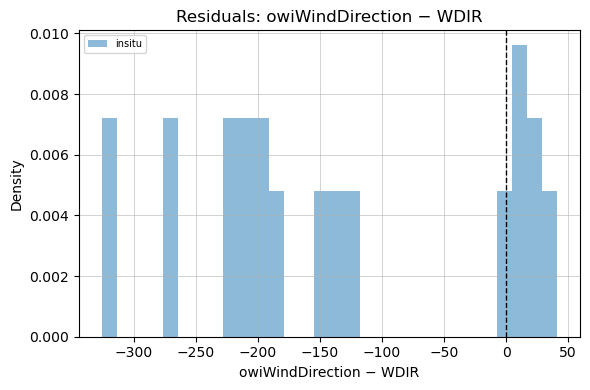

In [13]:
from sar_validation.core.visualization import validation_report

figures = validation_report(
    collocation_ds=collocation_ds,
    datatree=datatree,
    recipe=recipe,
    stats_ds_map=stats_map,
    out_dir=DATA_DIR,
)

print("Saved PNG files:")
for f in sorted((DATA_DIR / "plots").glob("*.png")):
    print(f"  {f.name}")